In [1]:
import pandas as pd
import numpy as np

# Import the dataset

In [2]:
df = pd.read_csv("../datasets/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 1. Generate Summary Statistics

In [3]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [4]:
print(df.median(numeric_only=True))

PassengerId    446.0000
Survived         0.0000
Pclass           3.0000
Age             28.0000
SibSp            0.0000
Parch            0.0000
Fare            14.4542
dtype: float64


In [5]:
print(df.mode().iloc[0])

PassengerId                      1
Survived                       0.0
Pclass                         3.0
Name           Abbing, Mr. Anthony
Sex                           male
Age                           24.0
SibSp                          0.0
Parch                          0.0
Ticket                        1601
Fare                          8.05
Cabin                      B96 B98
Embarked                         S
Name: 0, dtype: object


In [6]:
print(df.var(numeric_only=True))

PassengerId    66231.000000
Survived           0.236772
Pclass             0.699015
Age              211.019125
SibSp              1.216043
Parch              0.649728
Fare            2469.436846
dtype: float64


# 2.Create histograms and boxplots for numeric features. 

Histograms

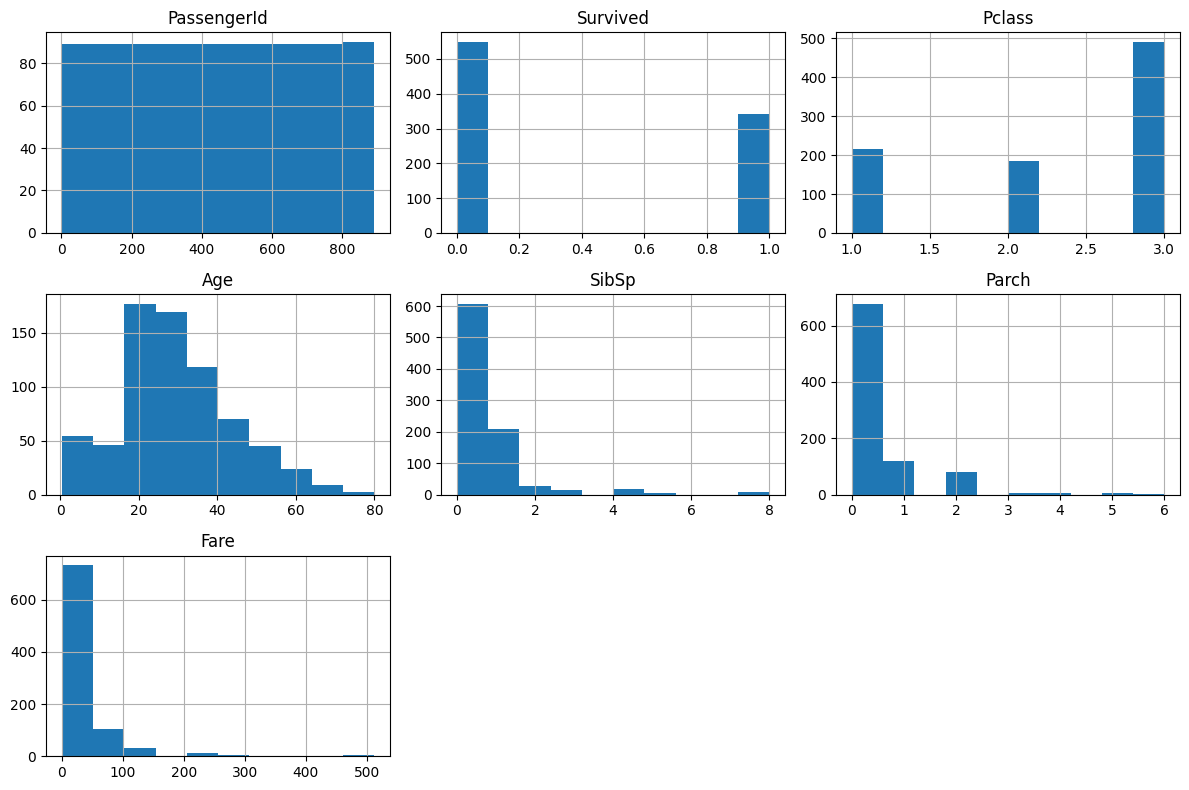

In [7]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))

plt.tight_layout()
plt.savefig("../images/histograms.png", dpi=300, bbox_inches="tight")
plt.show()

Boxplots

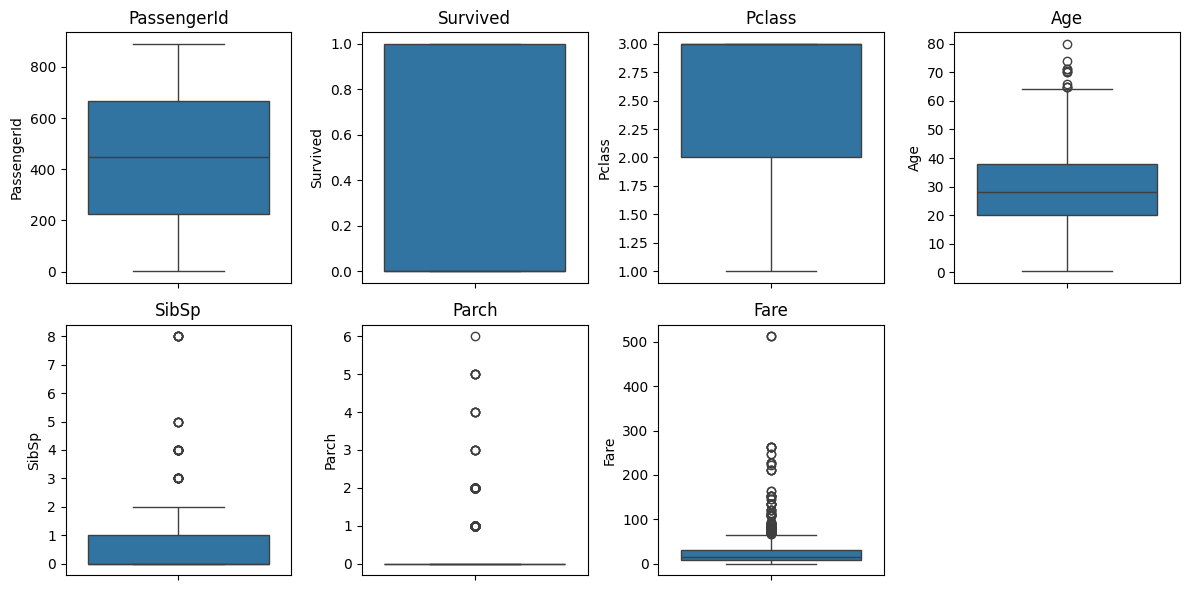

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(12,6))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, (len(numeric_cols)+1)//2, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.savefig("../images/boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

# 3.Use pairplot/correlation matrix for feature relationships. 

Pairplot

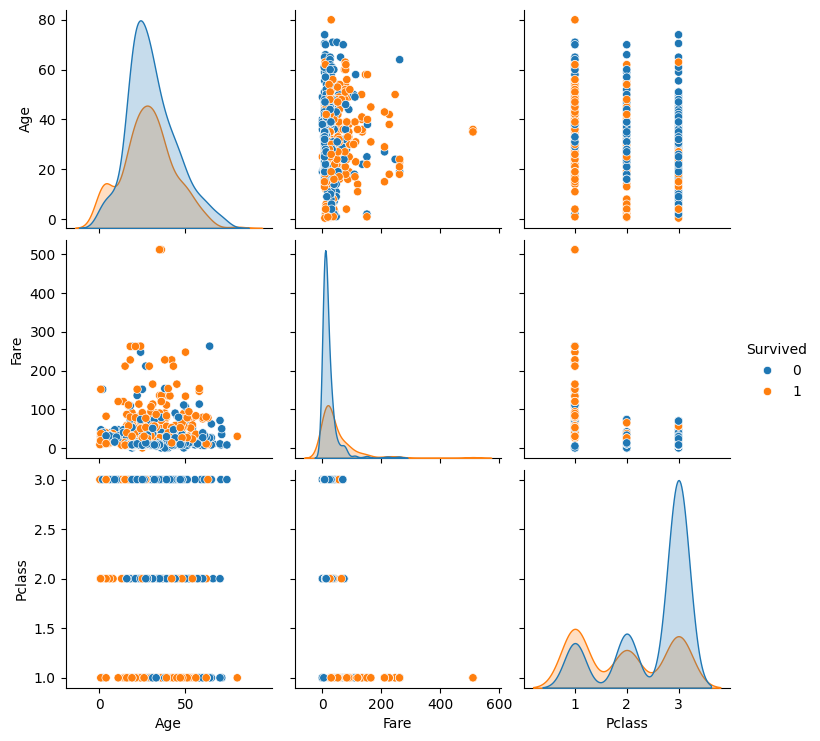

In [10]:
pair_plot = sns.pairplot(
    df,
    vars=["Age", "Fare", "Pclass"],
    hue="Survived"
)

pair_plot.savefig(
    "../images/pairplot.png",
    dpi=300
)

Correlation Matrix

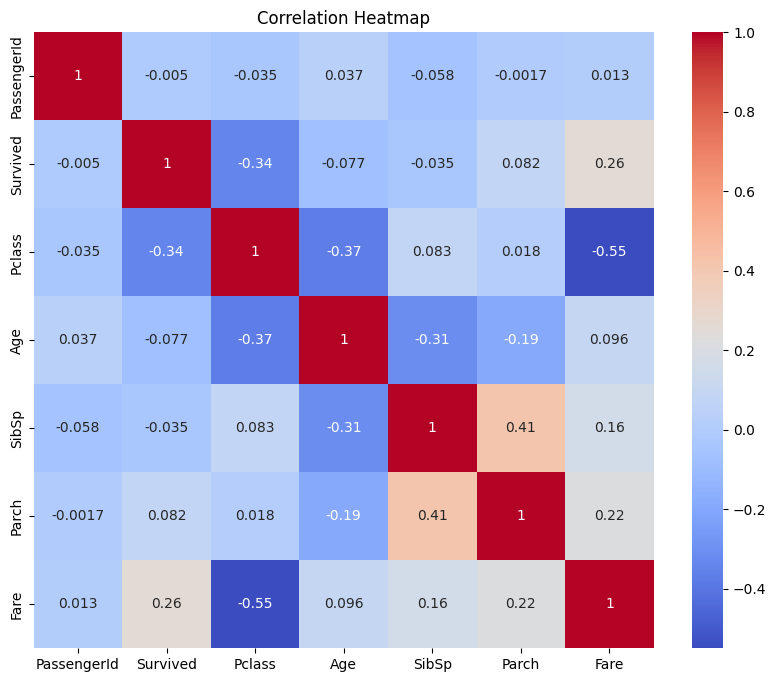

In [11]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 4.Identify patterns, trends, or anomalies in the data. 

Pattern
- Higher fares generally correspond to higher passenger class.

Trend
- Passengers in higher classes may have higher survival rates.

Anomaly
- Extremely high fare values compared to most passengers.

Missing Values
- Large number of missing values in Age or Cabin.

# 5.Make basic feature-level inferences from visuals.

Age
- Most passengers were between 20–40 years old.
- Age distribution is slightly right-skewed.
- Some missing values exist.

Fare
- Fare distribution is heavily right-skewed.
- Most passengers paid low fares.
- Several high-fare outliers are present.

Pclass
- Majority of passengers belonged to 3rd class.

Survival
- Survival appears related to passenger class and fare.

Correlation Analysis
- Fare and Pclass show moderate correlation.
- No strong linear relationship exists among most numerical variables.